In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report

In [47]:
iris = load_iris()
X = iris.data
y = pd.Series(iris.target, name="species")

In [48]:
# 1. Convert X to a DataFrame with correct column names
df = pd.DataFrame(X, columns=iris.feature_names)

# 2. Add the target series as a new column
df['species'] = y

In [49]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [50]:
X = pd.DataFrame(X)
X.columns = iris.feature_names

In [51]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [52]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int32

<Axes: xlabel='sepal length (cm)', ylabel='species'>

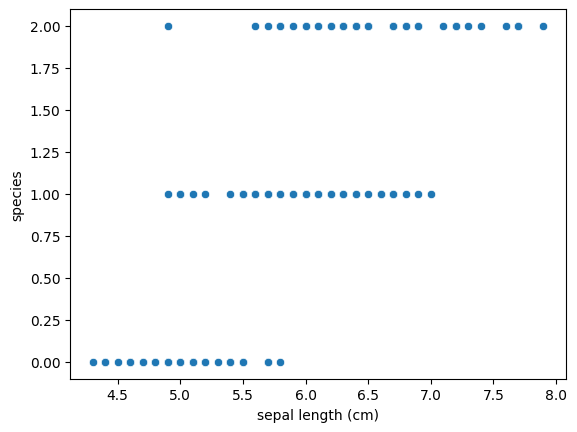

In [53]:
sns.scatterplot(data=X,x='sepal length (cm)',y=y)

<Axes: xlabel='sepal width (cm)', ylabel='species'>

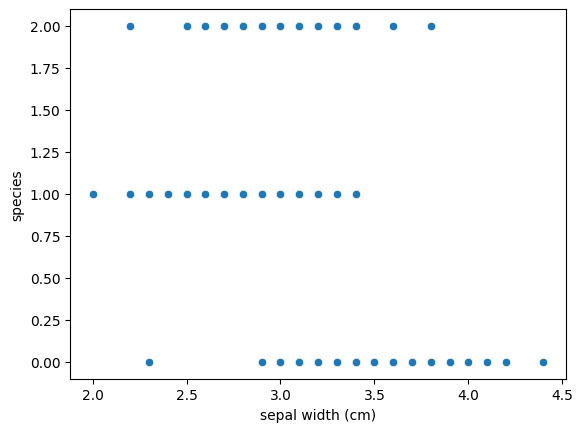

In [54]:
sns.scatterplot(data=X,x='sepal width (cm)',y=y)

<Axes: xlabel='petal length (cm)', ylabel='species'>

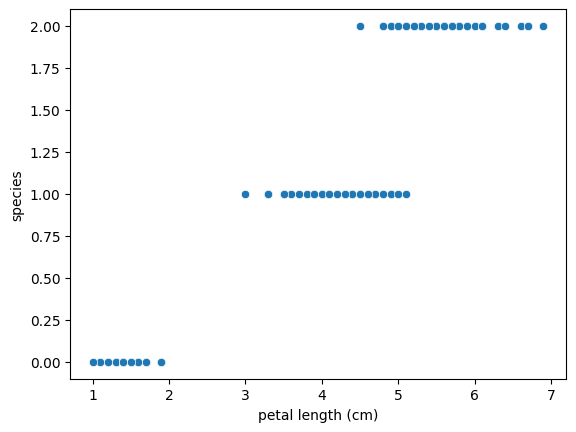

In [55]:
sns.scatterplot(data=X,x='petal length (cm)',y=y)

<Axes: xlabel='petal width (cm)', ylabel='species'>

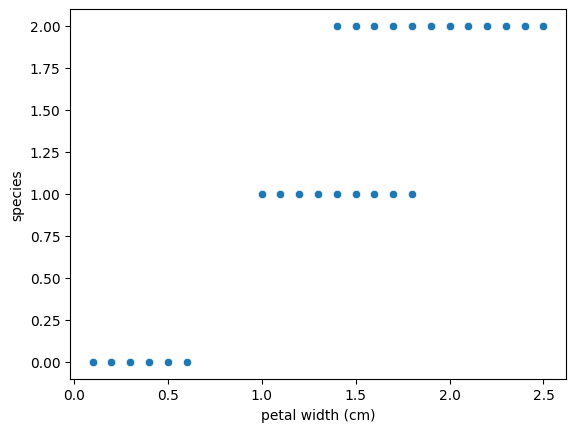

In [56]:
sns.scatterplot(data=X,x='petal width (cm)', y=y)

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

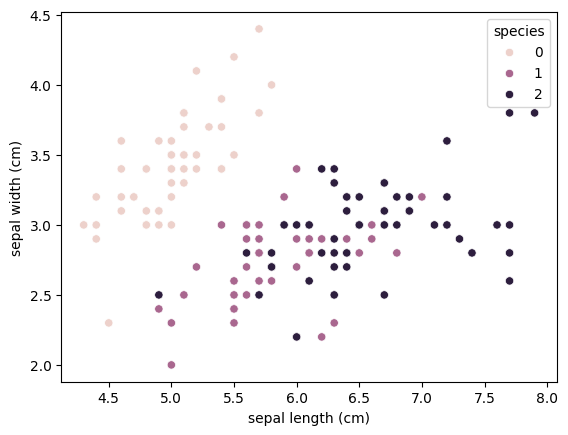

In [57]:
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)',hue='species')

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

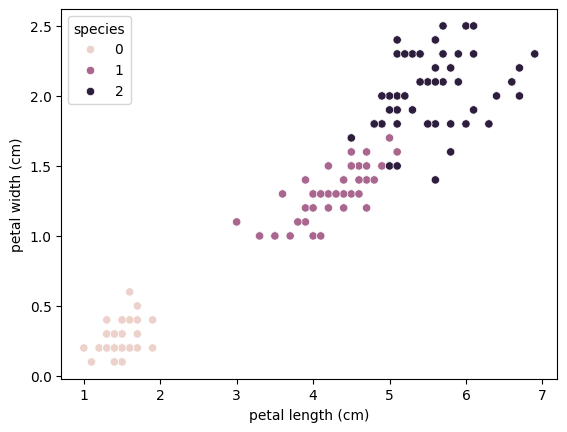

In [58]:
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)',hue='species')

In [59]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
perceptron = Perceptron(max_iter=10000, eta0=0.01, random_state=42)
perceptron.fit(X_train, y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,10000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,0.01
,n_jobs,None
,random_state,42


In [61]:
y_pred_train = perceptron.predict(X_train)
y_pred_test = perceptron.predict(X_test)

In [62]:
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred_test))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))

Train Accuracy: 0.8166666666666667
Test Accuracy : 0.9333333333333333

Classification Report (Test):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      1.00      0.90         9
           2       1.00      0.82      0.90        11

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.93        30
weighted avg       0.95      0.93      0.93        30



In [63]:
iris = load_iris()
X = iris.data   # Features: Sepal length, Sepal width, Petal length, Petal width
y = iris.target # Labels: 0, 1, 2 (Setosa, Versicolor, Virginica)

In [64]:
# -------------------------------
# For simplicity, we do a binary classification:
# Let's classify Setosa (0) vs not-Setosa (1)
# -------------------------------
y_binary = np.where(y == 0, 0, 1) #np.where(condition, A, B)

# -------------------------------
# Split into train and test
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.3, random_state=42
)

# -------------------------------
# Scale the features
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# Initialize and train Perceptron
# -------------------------------
perceptron = Perceptron(max_iter=10000, eta0=0.01, random_state=1)
perceptron.fit(X_train, y_train)

# -------------------------------
# Make predictions
# -------------------------------
y_pred_train = perceptron.predict(X_train)
y_pred_test = perceptron.predict(X_test)

# -------------------------------
# Evaluate the model
# -------------------------------
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred_test))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))

Train Accuracy: 1.0
Test Accuracy : 1.0

Classification Report (Test):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        26

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [66]:
# -------------------------------
# For simplicity, we do a binary classification:
# Let's classify Setosa (0) vs not-Setosa (1)
# -------------------------------
y_binary = np.where(y == 1, 1, 0) #np.where(condition, A, B)

# -------------------------------
# Split into train and test
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.3, random_state=42
)

# -------------------------------
# Scale the features
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# Initialize and train Perceptron
# -------------------------------
perceptron = Perceptron(max_iter=10000, eta0=0.01, random_state=1)
perceptron.fit(X_train, y_train)

# -------------------------------
# Make predictions
# -------------------------------
y_pred_train = perceptron.predict(X_train)
y_pred_test = perceptron.predict(X_test)

# -------------------------------
# Evaluate the model
# -------------------------------
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred_test))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))

Train Accuracy: 0.7238095238095238
Test Accuracy : 0.7333333333333333

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.78      0.88      0.82        32
           1       0.56      0.38      0.45        13

    accuracy                           0.73        45
   macro avg       0.67      0.63      0.64        45
weighted avg       0.71      0.73      0.72        45



In [67]:
# -------------------------------
# For simplicity, we do a binary classification:
# Let's classify Setosa (0) vs not-Setosa (1)
# -------------------------------
y_binary = np.where(y == 2, 1, 0) #np.where(condition, A, B)

# -------------------------------
# Split into train and test
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.3, random_state=42
)

# -------------------------------
# Scale the features
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# Initialize and train Perceptron
# -------------------------------
perceptron = Perceptron(max_iter=10000, eta0=0.01, random_state=1)
perceptron.fit(X_train, y_train)

# -------------------------------
# Make predictions
# -------------------------------
y_pred_train = perceptron.predict(X_train)
y_pred_test = perceptron.predict(X_test)

# -------------------------------
# Evaluate the model
# -------------------------------
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred_test))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))

Train Accuracy: 0.9619047619047619
Test Accuracy : 0.9777777777777777

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        32
           1       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.96      0.97        45
weighted avg       0.98      0.98      0.98        45

